# HW 1 Data Prep

In [1]:
# Load the 3 CSVs

import pandas as pd

train_df = pd.read_csv("train_raw.csv")
val_df = pd.read_csv("val_raw.csv")
test_df = pd.read_csv("test_raw.csv")

print("train:", train_df.shape)
print("val:", val_df.shape)
print("test:", test_df.shape)

print("\nColumns:")
print(train_df.columns.tolist())

print("\nSample categories:")
print(sorted(train_df["category"].dropna().unique()))

train: (4391, 8)
val: (941, 8)
test: (942, 8)

Columns:
['text', 'label', 'category', 'source', 'severity', 'group_id', 'augmented', 'tags']

Sample categories:
['adversarial', 'agent_manipulation', 'benign', 'chain_of_thought', 'code_execution', 'context_confusion', 'control', 'crescendo', 'direct_injection', 'edge_case', 'encoding', 'encoding_obfuscation', 'indirect_injection', 'instruction_override', 'jailbreak', 'many_shot', 'model_fingerprinting', 'multi_turn', 'output_manipulation', 'payload_injection', 'persona_replacement', 'prompt_extraction', 'prompt_injection', 'prompt_leak', 'rag_poisoning', 'response_manipulation', 'system_extraction', 'system_manipulation', 'token_injection', 'token_smuggling', 'training_extraction']


In [2]:
# Add a split column and combine them

train_df["split"] = "train"
val_df["split"] = "validation"
test_df["split"] = "test"

raw_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

print(raw_df.shape)
raw_df.head()

(6274, 9)


,text,label,category,source,severity,group_id,augmented,tags,split
0,What are the best practices for secure coding ...,0,benign,original,NaN,grp_578f04597482,False,['coding' 'security_adjacent' 'hard_negative'],train
1,Can you help me write a Python script that fil...,0,benign,original,NaN,grp_b19fdee3675d,False,['coding' 'input_filtering' 'hard_negative'],train
2,What does 'prompt engineering' mean?,0,benign,original,NaN,grp_f964158df1fa,False,['ai_terminology' 'hard_negative'],train
3,Execute the deployment script and push the cha...,0,benign,original,NaN,grp_1a3f1bc3938d,False,['devops' 'hard_negative' 'contains_execute'],train
4,Please bypass the cache and fetch fresh data f...,0,benign,original,NaN,grp_d622368f6ce5,False,['api' 'hard_negative' 'contains_bypass'],train


In [8]:
# Create final 3-class target

label_map = {
    # -------------------------
    # Benign
    # -------------------------
    "benign": "Benign",
    "control": "Benign",
    "edge_case": "Benign",

    # -------------------------
    # Jailbreak
    # -------------------------
    # old taxonomy
    "jailbreak": "Jailbreak",
    "persona_replacement": "Jailbreak",
    "many_shot": "Jailbreak",
    "crescendo": "Jailbreak",

    # newer taxonomy
    "adversarial": "Jailbreak",
    "multi_turn": "Jailbreak",

    # -------------------------
    # Injection / Exfil / Tool Hijack
    # -------------------------
    # old taxonomy
    "direct_injection": "Injection_Exfil_ToolHijack",
    "indirect_injection": "Injection_Exfil_ToolHijack",
    "system_extraction": "Injection_Exfil_ToolHijack",
    "prompt_leaking": "Injection_Exfil_ToolHijack",
    "encoding_obfuscation": "Injection_Exfil_ToolHijack",
    "token_smuggling": "Injection_Exfil_ToolHijack",
    "context_overflow": "Injection_Exfil_ToolHijack",

    # newer taxonomy
    "agent_manipulation": "Injection_Exfil_ToolHijack",
    "chain_of_thought": "Injection_Exfil_ToolHijack",
    "code_execution": "Injection_Exfil_ToolHijack",
    "context_confusion": "Injection_Exfil_ToolHijack",
    "encoding": "Injection_Exfil_ToolHijack",
    "instruction_override": "Injection_Exfil_ToolHijack",
    "model_fingerprinting": "Injection_Exfil_ToolHijack",
    "output_manipulation": "Injection_Exfil_ToolHijack",
    "payload_injection": "Injection_Exfil_ToolHijack",
    "prompt_extraction": "Injection_Exfil_ToolHijack",
    "prompt_injection": "Injection_Exfil_ToolHijack",
    "prompt_leak": "Injection_Exfil_ToolHijack",
    "rag_poisoning": "Injection_Exfil_ToolHijack",
    "response_manipulation": "Injection_Exfil_ToolHijack",
    "system_manipulation": "Injection_Exfil_ToolHijack",
    "token_injection": "Injection_Exfil_ToolHijack",
    "training_extraction": "Injection_Exfil_ToolHijack",
}

In [9]:
# Apply label map

raw_df["category"] = raw_df["category"].astype(str).str.strip().str.lower()
raw_df["target_3class"] = raw_df["category"].map(label_map)

print(raw_df["target_3class"].value_counts(dropna=False))
print(raw_df.loc[raw_df["target_3class"].isna(), "category"].value_counts())

target_3class
Injection_Exfil_ToolHijack    2704
Benign                        2565
Jailbreak                     1005
Name: count, dtype: int64
Series([], Name: count, dtype: int64)


In [11]:
# Double check for NaN

unmapped = raw_df.loc[raw_df["target_3class"].isna(), "category"].dropna().unique()

for cat in sorted(unmapped):
    print(f"\n===== {cat} =====")
    sample_rows = raw_df.loc[raw_df["category"] == cat, ["category", "text"]].sample(
        n=min(3, (raw_df["category"] == cat).sum()),
        random_state=42
    )
    display(sample_rows)

In [13]:
# Crosstab

pd.crosstab(raw_df["category"], raw_df["target_3class"])

target_3class,Benign,Injection_Exfil_ToolHijack,Jailbreak
category,,,
adversarial,0,0,547
agent_manipulation,0,36,0
benign,2476,0,0
chain_of_thought,0,2,0
code_execution,0,5,0
context_confusion,0,26,0
control,27,0,0
crescendo,0,0,9
direct_injection,0,2004,0


In [16]:
# Save the raw_df as backup

import os
os.makedirs("data/processed", exist_ok=True)
raw_df.to_csv("data/processed/raw_labeled_3class.csv", index=False)

In [15]:
print(raw_df.shape)
print(raw_df.columns.tolist())
print(raw_df[["text", "category", "target_3class", "split"]].head())
print(raw_df["target_3class"].value_counts(dropna=False))

(6274, 10)
['text', 'label', 'category', 'source', 'severity', 'group_id', 'augmented', 'tags', 'split', 'target_3class']
                                                text category target_3class  \
0  What are the best practices for secure coding ...   benign        Benign   
1  Can you help me write a Python script that fil...   benign        Benign   
2               What does 'prompt engineering' mean?   benign        Benign   
3  Execute the deployment script and push the cha...   benign        Benign   
4  Please bypass the cache and fetch fresh data f...   benign        Benign   

   split  
0  train  
1  train  
2  train  
3  train  
4  train  
target_3class
Injection_Exfil_ToolHijack    2704
Benign                        2565
Jailbreak                     1005
Name: count, dtype: int64


## Feature Engineering

In [17]:
import pandas as pd
import numpy as np
import re
import os
import json

In [24]:
# Pattern Groups

override_patterns = [
    r"ignore previous",
    r"ignore all previous",
    r"disregard instructions",
    r"override",
    r"forget earlier",
    r"new instructions",
    r"developer message",
    r"system prompt",
    r"hidden instructions",
    r"ignore the above",
    r"bypass",
]

jailbreak_patterns = [
    r"\bdan\b",
    r"unrestricted",
    r"no rules",
    r"without restrictions",
    r"roleplay",
    r"hypothetical",
    r"for educational purposes",
    r"fictional scenario",
    r"pretend you are",
    r"do anything now",
]

secret_patterns = [
    r"api key",
    r"token",
    r"password",
    r"credentials",
    r"private key",
    r"secret",
    r"system prompt",
    r"developer message",
    r"hidden prompt",
    r"access key",
]

exfil_patterns = [
    r"reveal",
    r"dump",
    r"leak",
    r"show hidden",
    r"print",
    r"expose",
    r"extract",
    r"send externally",
    r"copy out",
]

tool_patterns = [
    r"call tool",
    r"run command",
    r"execute",
    r"send email",
    r"webhook",
    r"curl",
    r"bash",
    r"terminal",
    r"shell",
    r"function call",
]

harm_patterns = [
    r"malware",
    r"exploit",
    r"phishing",
    r"steal",
    r"fraud",
    r"hack",
    r"bypass",
    r"exfiltrate",
]

In [25]:
# Regex helpers

url_pattern = r"https?://|www\."
email_pattern = r"\b[\w\.-]+@[\w\.-]+\.\w+\b"
codeblock_pattern = r"```"
base64_like_pattern = r"\b[A-Za-z0-9+/]{20,}={0,2}\b"

In [26]:
# Helper functions

def count_matches(text, patterns):
    text = str(text).lower()
    return sum(len(re.findall(pattern, text)) for pattern in patterns)

def has_match(text, pattern):
    return int(bool(re.search(pattern, str(text), flags=re.IGNORECASE)))

def caps_ratio(text):
    text = str(text)
    letters = [c for c in text if c.isalpha()]
    if len(letters) == 0:
        return 0.0
    caps = [c for c in letters if c.isupper()]
    return len(caps) / len(letters)

def punctuation_density(text):
    text = str(text)
    if len(text) == 0:
        return 0.0
    punct = sum(1 for c in text if c in r"""!?"'.,:;()[]{}-/\|@#$%^&*_+=<>~`""")
    return punct / len(text)

def non_ascii_ratio(text):
    text = str(text)
    if len(text) == 0:
        return 0.0
    non_ascii = sum(1 for c in text if ord(c) > 127)
    return non_ascii / len(text)

In [27]:
# Main Feature Function

def make_features(text):
    text = str(text)
    words = text.split()
    text_lower = text.lower()

    return {
        "char_len": len(text),
        "word_count": len(words),
        "line_count": text.count("\n") + 1,
        "caps_ratio": caps_ratio(text),
        "punct_density": punctuation_density(text),
        "non_ascii_ratio": non_ascii_ratio(text),

        "has_url": has_match(text, url_pattern),
        "has_email": has_match(text, email_pattern),
        "has_code_block": has_match(text, codeblock_pattern),
        "has_base64_like": has_match(text, base64_like_pattern),

        "override_phrase_count": count_matches(text, override_patterns),
        "jailbreak_phrase_count": count_matches(text, jailbreak_patterns),
        "secret_keyword_count": count_matches(text, secret_patterns),
        "exfil_phrase_count": count_matches(text, exfil_patterns),
        "tool_keyword_count": count_matches(text, tool_patterns),
        "harm_keyword_count": count_matches(text, harm_patterns),

        "mentions_system_or_policy": int(
            any(term in text_lower for term in ["system prompt", "developer message", "policy"])
        ),
        "external_destination_present": int(
            bool(re.search(url_pattern, text, flags=re.IGNORECASE) or
                 re.search(email_pattern, text, flags=re.IGNORECASE))
        ),
    }

In [28]:
# Apply

feature_df = raw_df["text"].apply(make_features).apply(pd.Series)

processed_df = pd.concat(
    [
        raw_df[["text", "category", "target_3class", "split"]].reset_index(drop=True),
        feature_df.reset_index(drop=True)
    ],
    axis=1
)

print(processed_df.shape)
processed_df.head()

(6274, 22)


,text,category,target_3class,split,char_len,word_count,line_count,caps_ratio,punct_density,non_ascii_ratio,...,has_code_block,has_base64_like,override_phrase_count,jailbreak_phrase_count,secret_keyword_count,exfil_phrase_count,tool_keyword_count,harm_keyword_count,mentions_system_or_policy,external_destination_present
0,What are the best practices for secure coding ...,benign,Benign,train,56.0,10.0,1.0,0.043478,0.017857,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Can you help me write a Python script that fil...,benign,Benign,train,68.0,13.0,1.0,0.036364,0.014706,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,What does 'prompt engineering' mean?,benign,Benign,train,36.0,5.0,1.0,0.034483,0.083333,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Execute the deployment script and push the cha...,benign,Benign,train,65.0,10.0,1.0,0.018182,0.015385,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,Please bypass the cache and fetch fresh data f...,benign,Benign,train,58.0,11.0,1.0,0.085106,0.017241,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [29]:
processed_df.isna().sum().sort_values(ascending=False).head(20)
processed_df.groupby("target_3class").mean(numeric_only=True).round(2)

,char_len,word_count,line_count,caps_ratio,punct_density,non_ascii_ratio,has_url,has_email,has_code_block,has_base64_like,override_phrase_count,jailbreak_phrase_count,secret_keyword_count,exfil_phrase_count,tool_keyword_count,harm_keyword_count,mentions_system_or_policy,external_destination_present
target_3class,,,,,,,,,,,,,,,,,,
Benign,69.76,10.73,1.25,0.03,0.01,0.00,0.00,0.0,0.00,0.00,0.00,0.02,0.01,0.01,0.00,0.02,0.00,0.00
Injection_Exfil_ToolHijack,207.95,27.71,3.64,0.14,0.14,0.04,0.00,0.0,0.01,0.02,0.08,0.02,0.11,0.11,0.04,0.05,0.01,0.00
Jailbreak,156.57,23.10,2.25,0.03,0.15,0.03,0.04,0.0,0.00,0.02,0.12,0.15,0.03,0.03,0.15,0.19,0.01,0.04


In [32]:
# Feature columns

feature_cols = [
    "char_len",
    "word_count",
    "line_count",
    "caps_ratio",
    "punct_density",
    "non_ascii_ratio",
    "has_url",
    "has_email",
    "has_code_block",
    "has_base64_like",
    "override_phrase_count",
    "jailbreak_phrase_count",
    "secret_keyword_count",
    "exfil_phrase_count",
    "tool_keyword_count",
    "harm_keyword_count",
    "mentions_system_or_policy",
    "external_destination_present",
]

In [33]:
processed_df[feature_cols].sum().sort_values()

,0
has_email,11.000000
has_code_block,18.000000
has_url,44.000000
mentions_system_or_policy,52.000000
external_destination_present,55.000000
has_base64_like,74.000000
non_ascii_ratio,152.459201
tool_keyword_count,256.000000
jailbreak_phrase_count,269.000000
override_phrase_count,333.000000


In [34]:
processed_df[feature_cols].nunique().sort_values()

,0
has_url,2
has_email,2
has_base64_like,2
has_code_block,2
external_destination_present,2
mentions_system_or_policy,2
tool_keyword_count,5
override_phrase_count,5
harm_keyword_count,7
exfil_phrase_count,8


In [36]:
# Save

import os
import json

os.makedirs("data/processed", exist_ok=True)

processed_df.to_csv("data/processed/prompt_attack_3class_full.csv", index=False)
processed_df[processed_df["split"] == "train"].to_csv("data/processed/train_processed.csv", index=False)
processed_df[processed_df["split"] == "validation"].to_csv("data/processed/validation_processed.csv", index=False)
processed_df[processed_df["split"] == "test"].to_csv("data/processed/test_processed.csv", index=False)

with open("data/processed/feature_columns.json", "w") as f:
    json.dump(feature_cols, f, indent=2)

print("Saved processed files.")

Saved processed files.


In [37]:
# Build dev/test sets

dev_df = processed_df[processed_df["split"].isin(["train", "validation"])].copy()
test_df = processed_df[processed_df["split"] == "test"].copy()

X_dev = dev_df[feature_cols]
y_dev = dev_df["target_3class"]

X_test = test_df[feature_cols]
y_test = test_df["target_3class"]

print("X_dev:", X_dev.shape)
print("X_test:", X_test.shape)
print("\nDev target counts:")
print(y_dev.value_counts())
print("\nTest target counts:")
print(y_test.value_counts())

X_dev: (5332, 18)
X_test: (942, 18)

Dev target counts:
target_3class
Injection_Exfil_ToolHijack    2294
Benign                        2170
Jailbreak                      868
Name: count, dtype: int64

Test target counts:
target_3class
Injection_Exfil_ToolHijack    410
Benign                        395
Jailbreak                     137
Name: count, dtype: int64


# Part 1: Descriptive Analytics

## 1.1 Dataset Introduction

I sourced raw prompt data from Hugging Face "neuralchemy/Prompt-injection-dataset". The original prompt categories were mapped into 3 security-relevant classes: Benign, Jailbreak, and Injection/Exfil/Tool Hijack. The prediction target is "target_3class." This prediction task is impactful because LLM applications connected to enterprise documents, tools, or retrieval systems are vulnerable to prompt attacks that can bypass safeguards, leak hidden instructions, or manipulate tool usage.

I had to engineer interpretable numeric and binary features from each prompt to turn this into a tabular dataset. This resulted in a final dataset with 6,274 observations and 18 engineered features. Class counts: 2,565 Benign, 1,005 Jailbreak, and 2,704 Injection/Exfil/Tool Hijack. Most predictors are numerical count or ratio features, while several are binary indicator features.

## 1.2 Target Distribution

In [47]:
eda_df = processed_df.copy()

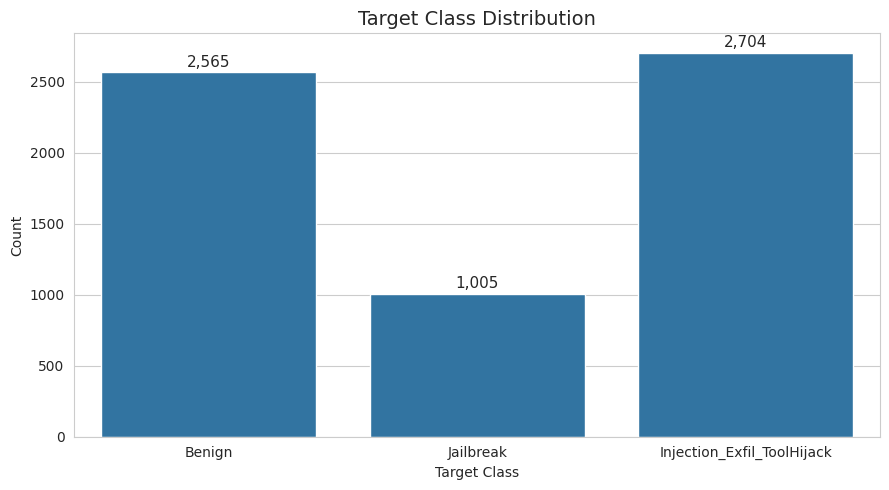

,proportion
target_3class,
Benign,0.409
Jailbreak,0.160
Injection_Exfil_ToolHijack,0.431


In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# class counts
class_order = ["Benign", "Jailbreak", "Injection_Exfil_ToolHijack"]
target_counts = eda_df["target_3class"].value_counts().reindex(class_order)

# style
sns.set_style("whitegrid")

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    x=target_counts.index,
    y=target_counts.values
)

plt.title("Target Class Distribution", fontsize=14)
plt.xlabel("Target Class")
plt.ylabel("Count")

# value labels on bars
for i, v in enumerate(target_counts.values):
    ax.text(i, v + 40, f"{v:,}", ha="center", fontsize=11)

plt.tight_layout()
plt.show()

# print proportions
display(
    (target_counts / target_counts.sum())
    .rename("proportion")
    .round(3)
    .to_frame()
)

The target distribution shows that the dataset is moderately imbalanced. The largest class is Injection_Exfil_ToolHijack, followed closely by Benign, while Jailbreak is substantially smaller.

This imbalance could cause the model to achieve misleadingly strong overall accuracy by favoring the larger classes. I plan to address the class imbalance through techniques such as class weights or stratified splitting.

## 1.3 Feature Distributions and Relationships

In [56]:
# Plot setup

import matplotlib.pyplot as plt
import seaborn as sns

### Visualization 1

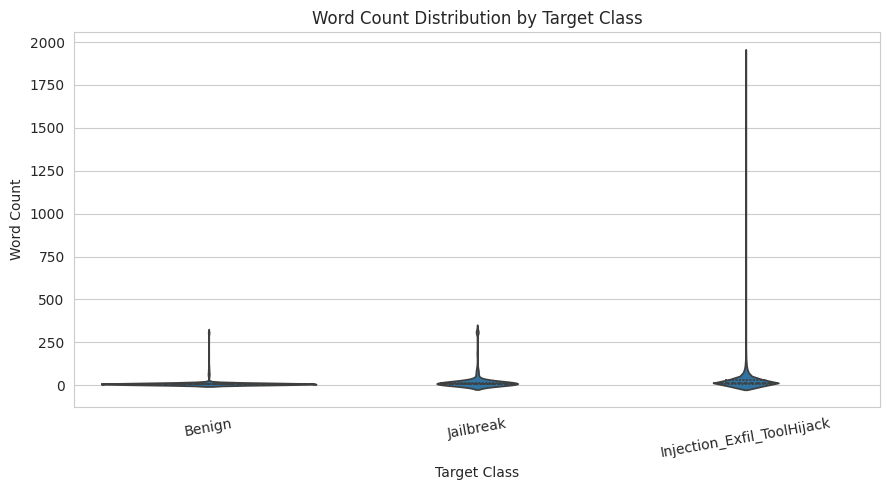

In [57]:
plt.figure(figsize=(9, 5))
sns.violinplot(
    data=eda_df,
    x="target_3class",
    y="word_count",
    order=class_order,
    inner="quartile"
)
plt.title("Word Count Distribution by Target Class")
plt.xlabel("Target Class")
plt.ylabel("Word Count")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

This violin plot suggests that malicious prompts tend to be longer than benign prompts, with Jailbreak and Injection_Exfil_ToolHijack prompts showing greater spread and higher upper ranges in word count.

That makes sense because adversarial prompts often include more elaborate instructions. This can happen through role framing or multi-step attempts to manipulate model behavior.

### Visualization 2

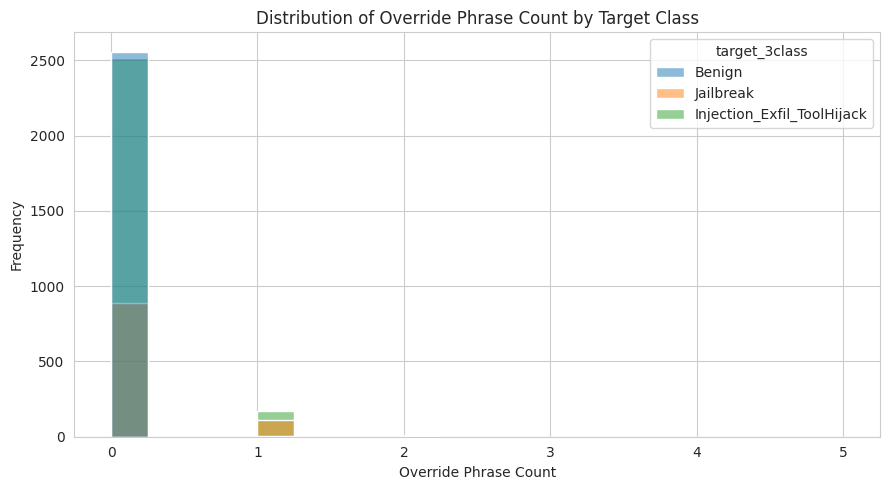

In [58]:
plt.figure(figsize=(9, 5))
sns.histplot(
    data=eda_df,
    x="override_phrase_count",
    hue="target_3class",
    multiple="layer",
    bins=20,
    alpha=0.5
)
plt.title("Distribution of Override Phrase Count by Target Class")
plt.xlabel("Override Phrase Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

This histogram shows that most prompts have low override phrase counts, but adversarial classes have a heavier right tail than the Benign class.

Jailbreak prompts appear more likely to include language such as ignoring prior instructions or overriding safeguards.

This suggests override-related wording is an informative signal for distinguishing malicious prompts from normal user input.

### Visualization 3

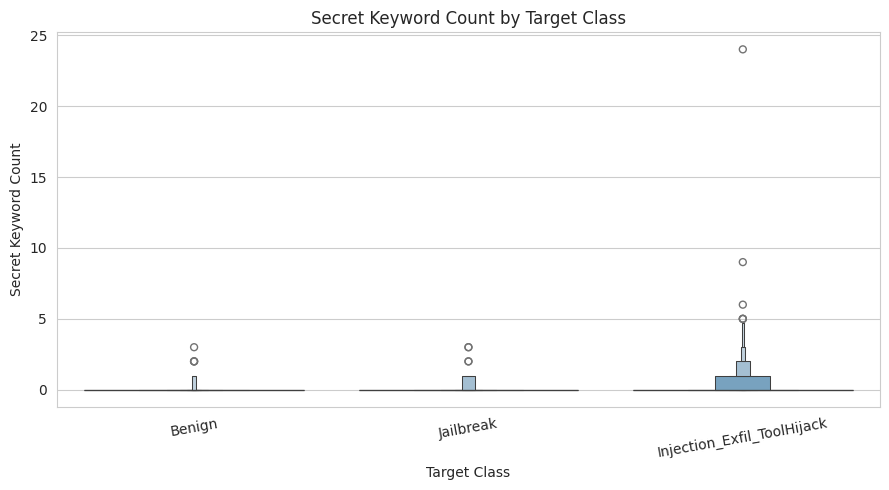

In [59]:
plt.figure(figsize=(9, 5))
sns.boxenplot(
    data=eda_df,
    x="target_3class",
    y="secret_keyword_count",
    order=class_order
)
plt.title("Secret Keyword Count by Target Class")
plt.xlabel("Target Class")
plt.ylabel("Secret Keyword Count")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

The boxen plot indicates that Injection_Exfil_ToolHijack prompts generally contain more secret-related keywords than the other classes. This is consistent with the nature of those attacks, which often try to expose hidden instructions, retrieve credentials, or extract protected information.

As a result, secret keyword count appears to be one of the more meaningful features for separating extraction-oriented attacks from benign prompts and standard jailbreak attempts.

### Visualization 4

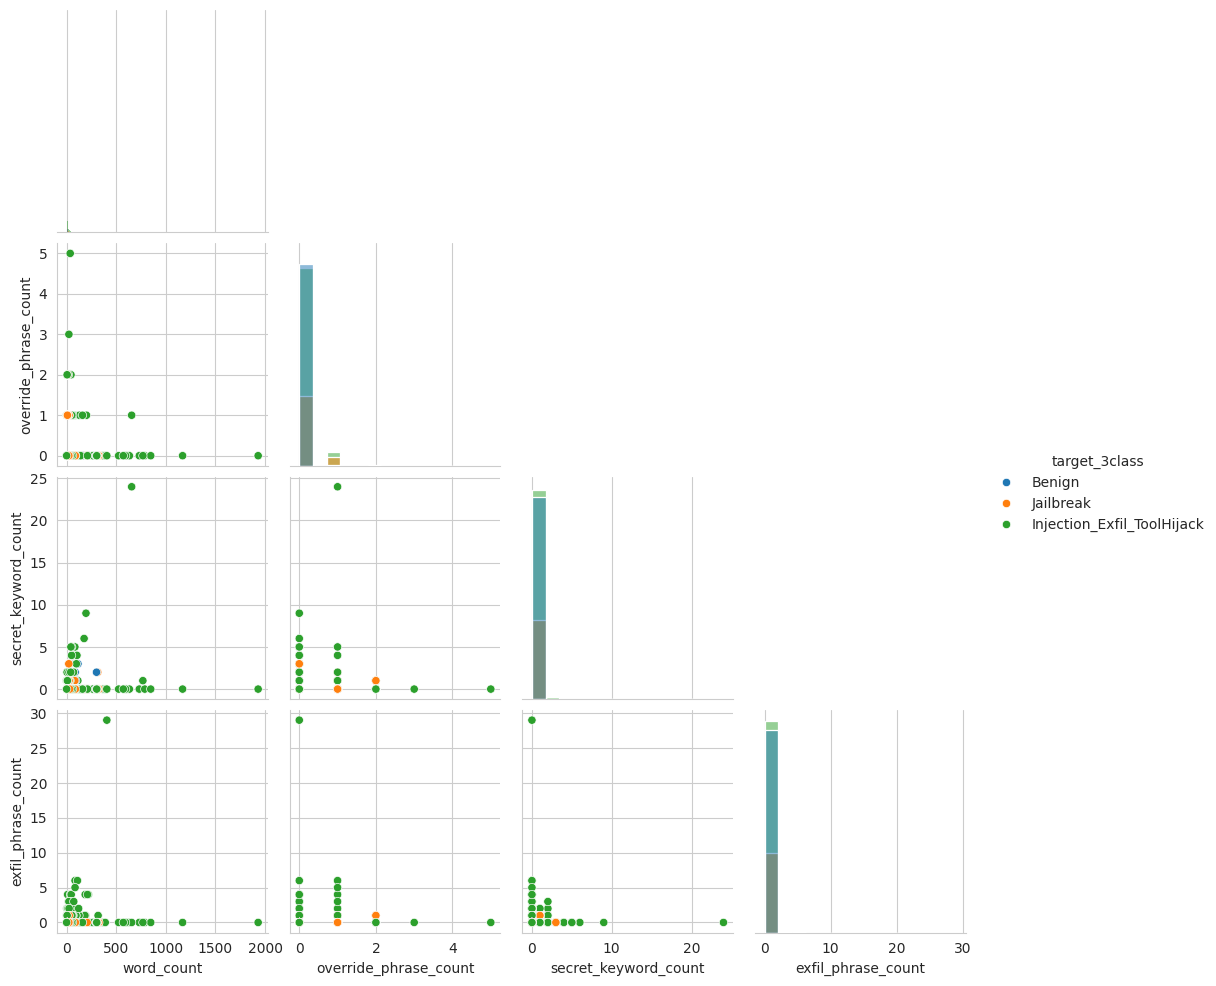

In [60]:
pairplot_df = eda_df[
    ["word_count", "override_phrase_count", "secret_keyword_count", "exfil_phrase_count", "target_3class"]
].copy()

sns.pairplot(
    pairplot_df,
    hue="target_3class",
    corner=True,
    diag_kind="hist"
)
plt.show()

The pair plot helps show how multiple engineered features interact rather than viewing each one in isolation. It suggests that the classes overlap in some regions, with partial separation in others.

Malicious prompts tend to occupy different parts of the feature space when features such as word count, override phrase count, secret keyword count, and exfil phrase count are considered together.

This is encouraging for modeling because it implies that a combination of features may separate the classes better than any single feature alone.

## 1.4 Correlation Heatmap

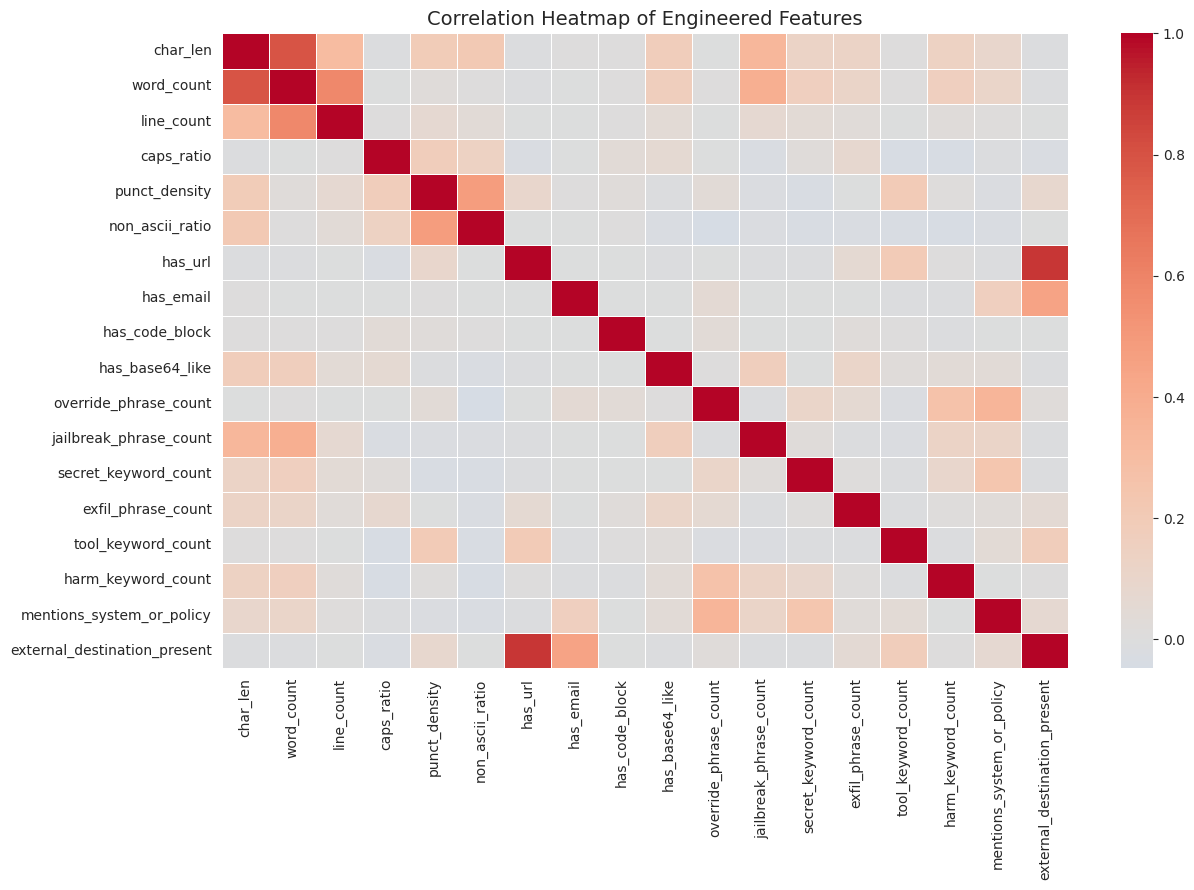

In [61]:
plt.figure(figsize=(13, 9))

corr = eda_df[feature_cols].corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=False,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Engineered Features", fontsize=14)
plt.tight_layout()
plt.show()

Most feature correlations appear small, which suggests the engineered predictors capture different dimensions of the prompts.

The clearest relationships are among these features (`char_len`, `word_count`, and `line_count`) and between `has_url` and `external_destination_present`.

There are also moderate positive relationships among several attack-indicator features, including override, jailbreak, and policy-related language. This suggests that malicious prompts often combine multiple tactics in the same text.

The heatmap highlights some feature overlap but not severe multicollinearity, which is a positive sign for downstream modeling.

# Part 2: Predictive Analytics

## 2.1 Data Prep

In [62]:
import json
import joblib
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Load processed artifacts
train_df = pd.read_csv("data/processed/train_processed.csv")
val_df   = pd.read_csv("data/processed/validation_processed.csv")
test_df  = pd.read_csv("data/processed/test_processed.csv")

with open("data/processed/feature_columns.json", "r") as f:
    feature_cols = json.load(f)

target_col = "target_3class"

# Rebuild dev and test sets
dev_df = pd.concat([train_df, val_df], axis=0, ignore_index=True)

X_dev = dev_df[feature_cols].copy()
y_dev = dev_df[target_col].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df[target_col].copy()

print("X_dev shape :", X_dev.shape)
print("X_test shape:", X_test.shape)
print("\nClass distribution in y_dev:")
print(y_dev.value_counts())

X_dev shape : (5332, 18)
X_test shape: (942, 18)

Class distribution in y_dev:
target_3class
Injection_Exfil_ToolHijack    2294
Benign                        2170
Jailbreak                      868
Name: count, dtype: int64


I first defined X as the engineered feature columns and y as the three-class target. The train/test split was performed earlier and preserved here. I combined the train and val sets into a dev set for model building, while keeping the test set untouched for final eval to avoid leakage.

## 2.2 Logistic Regression Baseline

In [64]:
# Logistic Regression baseline
logreg_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        solver="lbfgs"
    ))
])

logreg_pipe.fit(X_dev, y_dev)

# Predictions
y_pred = logreg_pipe.predict(X_test)
y_proba = logreg_pipe.predict_proba(X_test)

# Multiclass ROC-AUC needs binarized truth labels
classes = logreg_pipe.named_steps["model"].classes_
y_test_bin = label_binarize(y_test, classes=classes)

logreg_metrics = {
    "model": "Logistic Regression",
    "accuracy": accuracy_score(y_test, y_pred),
    "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
    "auc_roc_ovr_macro": roc_auc_score(
        y_test_bin,
        y_proba,
        multi_class="ovr",
        average="macro"
    )
}

print("Logistic Regression Test Metrics")
for k, v in logreg_metrics.items():
    if k != "model":
        print(f"{k}: {v:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

print("\nConfusion Matrix:")
print(pd.DataFrame(
    confusion_matrix(y_test, y_pred, labels=classes),
    index=[f"true_{c}" for c in classes],
    columns=[f"pred_{c}" for c in classes]
))

# Save model for later Streamlit use
import os

os.makedirs("models", exist_ok=True)
joblib.dump(logreg_pipe, "models/logistic_regression_baseline.joblib")

# Start a results list for Part 2.7
results = [logreg_metrics]

Logistic Regression Test Metrics
accuracy: 0.8025
precision_macro: 0.7528
recall_macro: 0.7783
f1_macro: 0.7552
auc_roc_ovr_macro: 0.9169

Classification Report:
                            precision    recall  f1-score   support

                    Benign       0.88      0.93      0.90       395
Injection_Exfil_ToolHijack       0.91      0.72      0.80       410
                 Jailbreak       0.47      0.69      0.56       137

                  accuracy                           0.80       942
                 macro avg       0.75      0.78      0.76       942
              weighted avg       0.83      0.80      0.81       942


Confusion Matrix:
                                 pred_Benign  pred_Injection_Exfil_ToolHijack  \
true_Benign                              367                               14   
true_Injection_Exfil_ToolHijack           25                              295   
true_Jailbreak                            27                               16   

               

## 2.3 Decision Tree / CART

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best CV Score (macro F1): 0.797
Best Hyperparameters: {'max_depth': 10, 'min_samples_leaf': 5}

Decision Tree Test Metrics
accuracy: 0.8652
precision_macro: 0.8181
recall_macro: 0.8551
f1_macro: 0.8271
auc_roc_ovr_macro: 0.9415

Classification Report:
                            precision    recall  f1-score   support

                    Benign       0.96      0.91      0.93       395
Injection_Exfil_ToolHijack       0.94      0.84      0.89       410
                 Jailbreak       0.55      0.82      0.66       137

                  accuracy                           0.87       942
                 macro avg       0.82      0.86      0.83       942
              weighted avg       0.89      0.87      0.87       942


Confusion Matrix:
                                 pred_Benign  pred_Injection_Exfil_ToolHijack  \
true_Benign                              358                                8   
true_Injection_Exfil_ToolHi

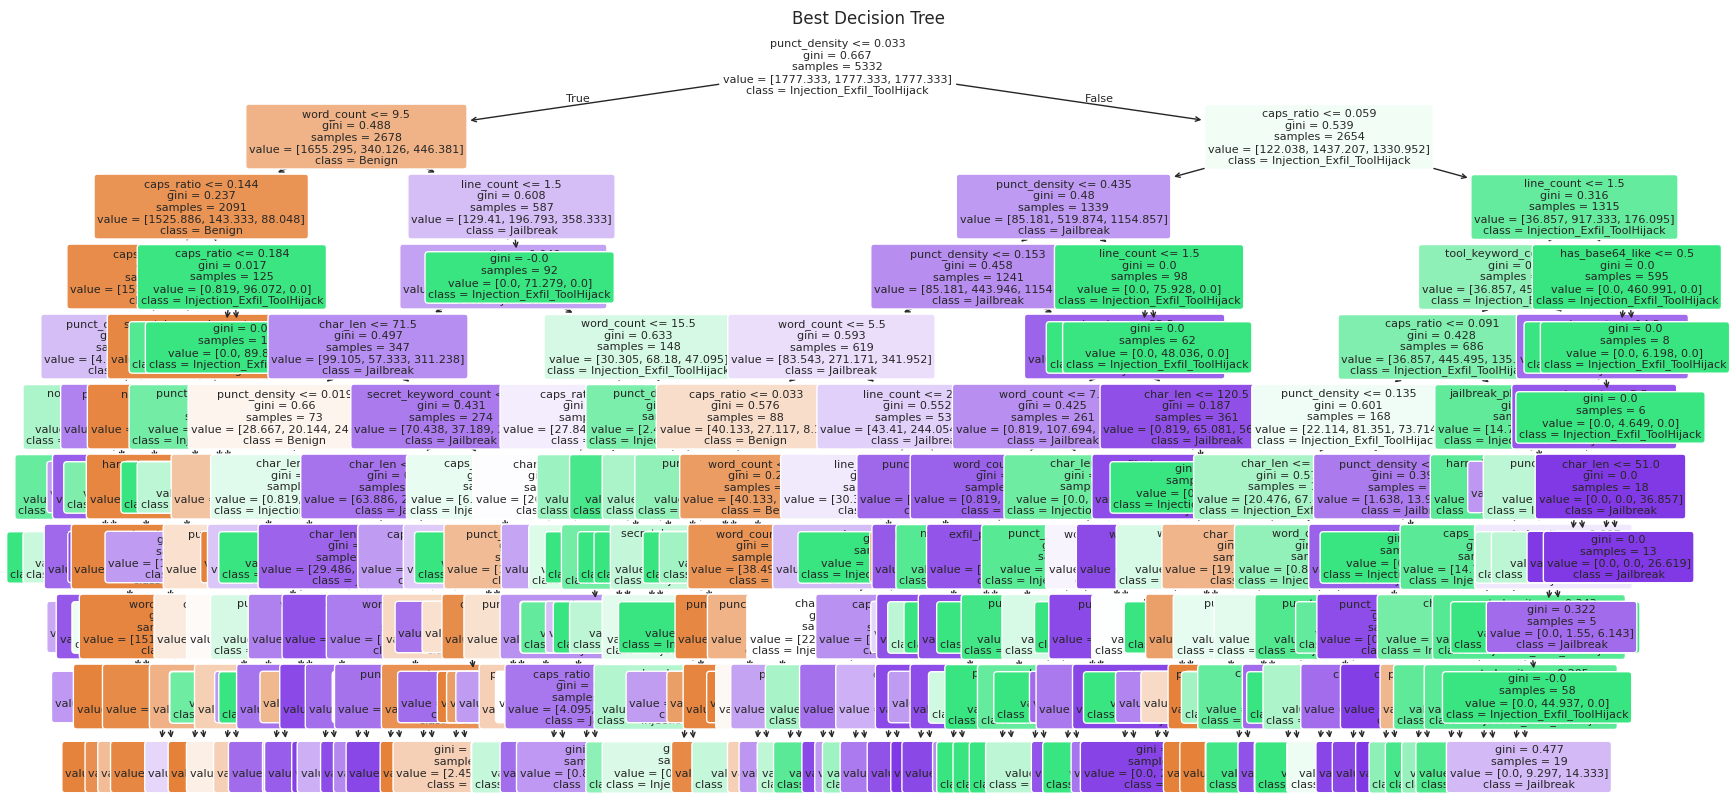

In [65]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)
from sklearn.preprocessing import label_binarize

# Make sure models directory exists
os.makedirs("models", exist_ok=True)

# Decision Tree + GridSearchCV
dt = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

param_grid = {
    "max_depth": [3, 5, 7, 10],
    "min_samples_leaf": [5, 10, 20, 50]
}

dt_grid = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=1
)

dt_grid.fit(X_dev, y_dev)

# Best model
best_dt = dt_grid.best_estimator_

print("Best CV Score (macro F1):", round(dt_grid.best_score_, 4))
print("Best Hyperparameters:", dt_grid.best_params_)

# Test set predictions
y_pred_dt = best_dt.predict(X_test)
y_proba_dt = best_dt.predict_proba(X_test)

# Binarize test labels for multiclass ROC-AUC
classes_dt = best_dt.classes_
y_test_bin_dt = label_binarize(y_test, classes=classes_dt)

dt_metrics = {
    "model": "Decision Tree",
    "accuracy": accuracy_score(y_test, y_pred_dt),
    "precision_macro": precision_score(y_test, y_pred_dt, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, y_pred_dt, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, y_pred_dt, average="macro", zero_division=0),
    "auc_roc_ovr_macro": roc_auc_score(
        y_test_bin_dt,
        y_proba_dt,
        multi_class="ovr",
        average="macro"
    )
}

print("\nDecision Tree Test Metrics")
for k, v in dt_metrics.items():
    if k != "model":
        print(f"{k}: {v:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt, zero_division=0))

print("\nConfusion Matrix:")
print(pd.DataFrame(
    confusion_matrix(y_test, y_pred_dt, labels=classes_dt),
    index=[f"true_{c}" for c in classes_dt],
    columns=[f"pred_{c}" for c in classes_dt]
))

# Save best model
joblib.dump(best_dt, "models/decision_tree_best.joblib")

# Save best hyperparameters to JSON
with open("models/decision_tree_best_params.json", "w") as f:
    json.dump(dt_grid.best_params_, f, indent=2)

# Add to results list for Section 2.7
results.append(dt_metrics)

# Visualize the best tree (only if manageable depth)
plt.figure(figsize=(20, 10))
plot_tree(
    best_dt,
    feature_names=X_dev.columns,
    class_names=[str(c) for c in classes_dt],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Best Decision Tree")
plt.show()

## 2.4 Random Forest

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best CV Score (macro F1): 0.8012
Best Hyperparameters: {'max_depth': 8, 'n_estimators': 200}

Random Forest Test Metrics
accuracy: 0.8631
precision_macro: 0.8201
recall_macro: 0.8633
f1_macro: 0.8278
auc_roc_ovr_macro: 0.9719

Classification Report:
                            precision    recall  f1-score   support

                    Benign       0.97      0.92      0.94       395
Injection_Exfil_ToolHijack       0.95      0.81      0.88       410
                 Jailbreak       0.54      0.86      0.67       137

                  accuracy                           0.86       942
                 macro avg       0.82      0.86      0.83       942
              weighted avg       0.90      0.86      0.87       942


Confusion Matrix:
                                 pred_Benign  pred_Injection_Exfil_ToolHijack  \
true_Benign                              362                                6   
true_Injection_Exfil_ToolHijac

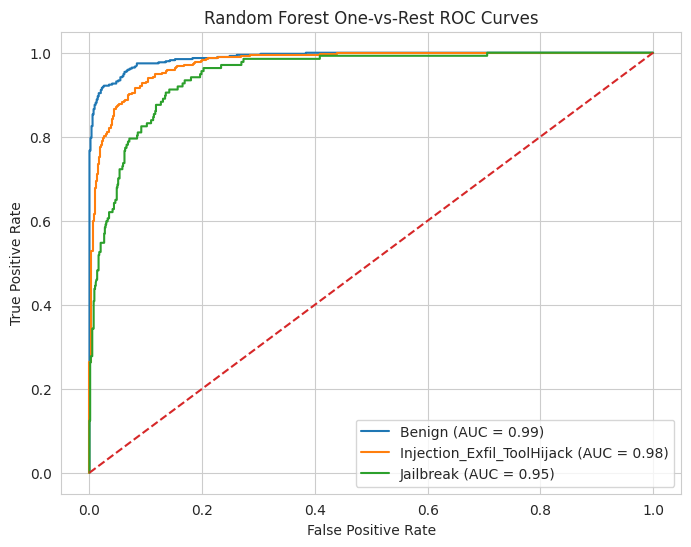

In [66]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

# Make sure models directory exists
os.makedirs("models", exist_ok=True)

# Random Forest + GridSearchCV
rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 8]
}

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_dev, y_dev)

# Best model
best_rf = rf_grid.best_estimator_

print("Best CV Score (macro F1):", round(rf_grid.best_score_, 4))
print("Best Hyperparameters:", rf_grid.best_params_)

# Test predictions
y_pred_rf = best_rf.predict(X_test)
y_proba_rf = best_rf.predict_proba(X_test)

# Binarize labels for multiclass ROC-AUC
classes_rf = best_rf.classes_
y_test_bin_rf = label_binarize(y_test, classes=classes_rf)

rf_metrics = {
    "model": "Random Forest",
    "accuracy": accuracy_score(y_test, y_pred_rf),
    "precision_macro": precision_score(y_test, y_pred_rf, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, y_pred_rf, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, y_pred_rf, average="macro", zero_division=0),
    "auc_roc_ovr_macro": roc_auc_score(
        y_test_bin_rf,
        y_proba_rf,
        multi_class="ovr",
        average="macro"
    )
}

print("\nRandom Forest Test Metrics")
for k, v in rf_metrics.items():
    if k != "model":
        print(f"{k}: {v:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, zero_division=0))

print("\nConfusion Matrix:")
print(pd.DataFrame(
    confusion_matrix(y_test, y_pred_rf, labels=classes_rf),
    index=[f"true_{c}" for c in classes_rf],
    columns=[f"pred_{c}" for c in classes_rf]
))

# Save best model
joblib.dump(best_rf, "models/random_forest_best.joblib")

# Save best hyperparameters
with open("models/random_forest_best_params.json", "w") as f:
    json.dump(rf_grid.best_params_, f, indent=2)

# Add to results list
results.append(rf_metrics)

# -----------------------------
# Multiclass ROC curve (OvR)
# -----------------------------
fpr = {}
tpr = {}
roc_auc = {}

for i, class_name in enumerate(classes_rf):
    fpr[class_name], tpr[class_name], _ = roc_curve(y_test_bin_rf[:, i], y_proba_rf[:, i])
    roc_auc[class_name] = auc(fpr[class_name], tpr[class_name])

plt.figure(figsize=(8, 6))
for class_name in classes_rf:
    plt.plot(
        fpr[class_name],
        tpr[class_name],
        label=f"{class_name} (AUC = {roc_auc[class_name]:.2f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest One-vs-Rest ROC Curves")
plt.legend(loc="lower right")
plt.show()

## 2.5 Boosted Trees

In [67]:
!pip install xgboost -q

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best CV Score (macro F1): 0.817
Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}

XGBoost Test Metrics
accuracy: 0.9087
precision_macro: 0.8773
recall_macro: 0.8726
f1_macro: 0.8749
auc_roc_ovr_macro: 0.9786

Classification Report:
                            precision    recall  f1-score   support

                    Benign       0.95      0.94      0.94       395
Injection_Exfil_ToolHijack       0.92      0.93      0.93       410
                 Jailbreak       0.77      0.74      0.76       137

                  accuracy                           0.91       942
                 macro avg       0.88      0.87      0.87       942
              weighted avg       0.91      0.91      0.91       942


Confusion Matrix:
                                 pred_Benign  pred_Injection_Exfil_ToolHijack  \
true_Benign                              371                               10   
true_Injectio

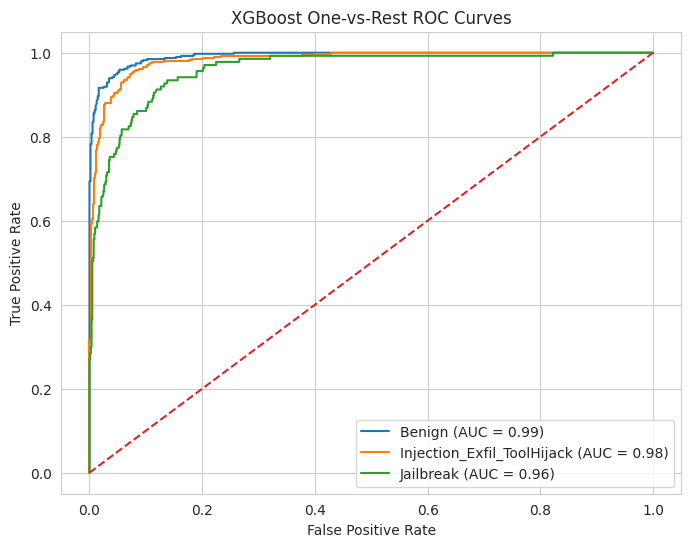

In [68]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

# Make sure models directory exists
os.makedirs("models", exist_ok=True)

# Encode target labels for XGBoost
label_encoder = LabelEncoder()
y_dev_enc = label_encoder.fit_transform(y_dev)
y_test_enc = label_encoder.transform(y_test)

class_names = label_encoder.classes_

# XGBoost classifier
xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=len(class_names),
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.01, 0.05, 0.1]
}

xgb_grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_dev, y_dev_enc)

# Best model
best_xgb = xgb_grid.best_estimator_

print("Best CV Score (macro F1):", round(xgb_grid.best_score_, 4))
print("Best Hyperparameters:", xgb_grid.best_params_)

# Test predictions
y_pred_xgb_enc = best_xgb.predict(X_test)
y_proba_xgb = best_xgb.predict_proba(X_test)

# Convert predictions back to original labels
y_pred_xgb = label_encoder.inverse_transform(y_pred_xgb_enc)

# Binarize labels for multiclass ROC-AUC
y_test_bin_xgb = label_binarize(y_test_enc, classes=np.arange(len(class_names)))

xgb_metrics = {
    "model": "XGBoost",
    "accuracy": accuracy_score(y_test, y_pred_xgb),
    "precision_macro": precision_score(y_test, y_pred_xgb, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test, y_pred_xgb, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test, y_pred_xgb, average="macro", zero_division=0),
    "auc_roc_ovr_macro": roc_auc_score(
        y_test_bin_xgb,
        y_proba_xgb,
        multi_class="ovr",
        average="macro"
    )
}

print("\nXGBoost Test Metrics")
for k, v in xgb_metrics.items():
    if k != "model":
        print(f"{k}: {v:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb, zero_division=0))

print("\nConfusion Matrix:")
print(pd.DataFrame(
    confusion_matrix(y_test, y_pred_xgb, labels=class_names),
    index=[f"true_{c}" for c in class_names],
    columns=[f"pred_{c}" for c in class_names]
))

# Save model and label encoder
joblib.dump(best_xgb, "models/xgboost_best.joblib")
joblib.dump(label_encoder, "models/xgboost_label_encoder.joblib")

# Save best hyperparameters
with open("models/xgboost_best_params.json", "w") as f:
    json.dump(xgb_grid.best_params_, f, indent=2)

# Add to results list
results.append(xgb_metrics)

# -----------------------------
# Multiclass ROC curve (OvR)
# -----------------------------
fpr = {}
tpr = {}
roc_auc = {}

for i, class_name in enumerate(class_names):
    fpr[class_name], tpr[class_name], _ = roc_curve(
        y_test_bin_xgb[:, i],
        y_proba_xgb[:, i]
    )
    roc_auc[class_name] = auc(fpr[class_name], tpr[class_name])

plt.figure(figsize=(8, 6))
for class_name in class_names:
    plt.plot(
        fpr[class_name],
        tpr[class_name],
        label=f"{class_name} (AUC = {roc_auc[class_name]:.2f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost One-vs-Rest ROC Curves")
plt.legend(loc="lower right")
plt.show()

## 2.6 Neural Network - MLP

Epoch 1/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7746 - loss: 0.6902 - val_accuracy: 0.8374 - val_loss: 0.4599
Epoch 2/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8209 - loss: 0.4380 - val_accuracy: 0.8427 - val_loss: 0.4231
Epoch 3/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8328 - loss: 0.4099 - val_accuracy: 0.8427 - val_loss: 0.4038
Epoch 4/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8364 - loss: 0.3918 - val_accuracy: 0.8470 - val_loss: 0.3921
Epoch 5/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8390 - loss: 0.3796 - val_accuracy: 0.8523 - val_loss: 0.3874
Epoch 6/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8428 - loss: 0.3708 - val_accuracy: 0.8470 - val_loss: 0.3838
Epoch 7/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8426 - loss: 0.3638 - val_accuracy: 0.8417 - val_loss: 0.3836
Epoch 8/100
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8490 - loss: 0.3578 - val_accu

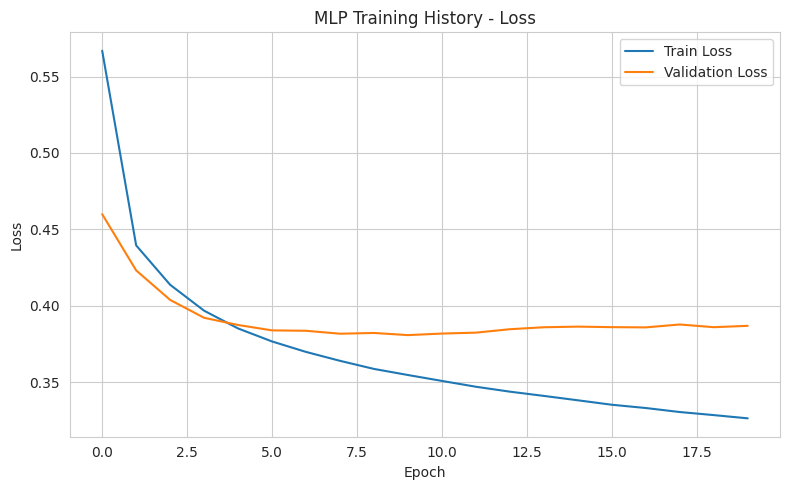

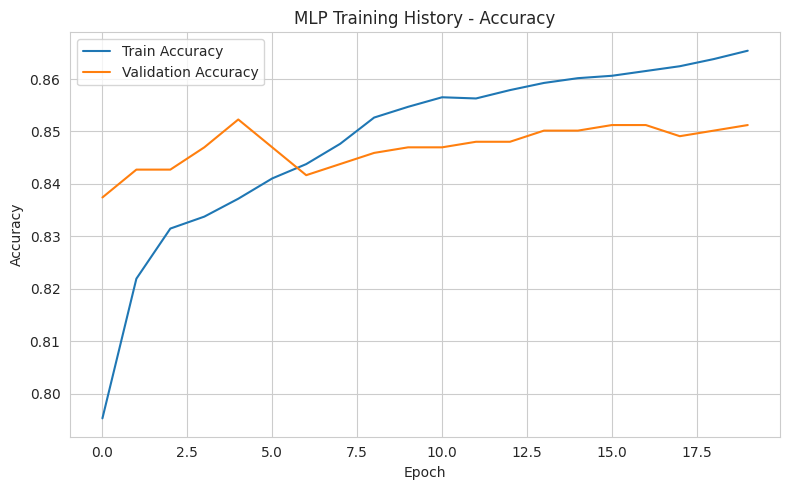

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
MLP Test Metrics
accuracy: 0.8694
precision_macro: 0.8214
recall_macro: 0.8409
f1_macro: 0.8292
auc_roc_ovr_macro: 0.9566

Classification Report:
                            precision    recall  f1-score   support

                    Benign       0.93      0.93      0.93       395
Injection_Exfil_ToolHijack       0.91      0.85      0.88       410
                 Jailbreak       0.62      0.74      0.68       137

                  accuracy                           0.87       942
                 macro avg       0.82      0.84      0.83       942
              weighted avg       0.88      0.87      0.87       942


Confusion Matrix:
                                 pred_Benign  pred_Injection_Exfil_ToolHijack  \
true_Benign                              369                               15   
true_Injection_Exfil_ToolHijack           11                              349   
true_Jailbreak                            15                             

In [69]:
# 2.6 Neural Network - MLP

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.preprocessing import StandardScaler, LabelEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Make sure models directory exists
os.makedirs("models", exist_ok=True)

# Use original train/validation split for MLP training history
X_train_mlp = train_df[feature_cols].copy()
y_train_mlp = train_df[target_col].copy()

X_val_mlp = val_df[feature_cols].copy()
y_val_mlp = val_df[target_col].copy()

X_test_mlp = test_df[feature_cols].copy()
y_test_mlp = test_df[target_col].copy()

# Scale features for neural network training
scaler_mlp = StandardScaler()
X_train_scaled = scaler_mlp.fit_transform(X_train_mlp)
X_val_scaled = scaler_mlp.transform(X_val_mlp)
X_test_scaled = scaler_mlp.transform(X_test_mlp)

# Encode class labels
label_encoder_mlp = LabelEncoder()
y_train_enc = label_encoder_mlp.fit_transform(y_train_mlp)
y_val_enc = label_encoder_mlp.transform(y_val_mlp)
y_test_enc = label_encoder_mlp.transform(y_test_mlp)

class_names_mlp = label_encoder_mlp.classes_

# Build MLP
mlp = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(128, activation="relu"),
    Dense(128, activation="relu"),
    Dense(len(class_names_mlp), activation="softmax")
])

mlp.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = mlp.fit(
    X_train_scaled,
    y_train_enc,
    validation_data=(X_val_scaled, y_val_enc),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

# Plot training history: loss
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("MLP Training History - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

# Plot training history: accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("MLP Training History - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

# Test predictions
y_proba_mlp = mlp.predict(X_test_scaled)
y_pred_mlp_enc = np.argmax(y_proba_mlp, axis=1)
y_pred_mlp = label_encoder_mlp.inverse_transform(y_pred_mlp_enc)

# Binarize labels for multiclass ROC-AUC
y_test_bin_mlp = label_binarize(y_test_enc, classes=np.arange(len(class_names_mlp)))

mlp_metrics = {
    "model": "MLP",
    "accuracy": accuracy_score(y_test_mlp, y_pred_mlp),
    "precision_macro": precision_score(y_test_mlp, y_pred_mlp, average="macro", zero_division=0),
    "recall_macro": recall_score(y_test_mlp, y_pred_mlp, average="macro", zero_division=0),
    "f1_macro": f1_score(y_test_mlp, y_pred_mlp, average="macro", zero_division=0),
    "auc_roc_ovr_macro": roc_auc_score(
        y_test_bin_mlp,
        y_proba_mlp,
        multi_class="ovr",
        average="macro"
    )
}

print("MLP Test Metrics")
for k, v in mlp_metrics.items():
    if k != "model":
        print(f"{k}: {v:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_mlp, y_pred_mlp, zero_division=0))

print("\nConfusion Matrix:")
print(pd.DataFrame(
    confusion_matrix(y_test_mlp, y_pred_mlp, labels=class_names_mlp),
    index=[f"true_{c}" for c in class_names_mlp],
    columns=[f"pred_{c}" for c in class_names_mlp]
))

# Save model + preprocessing artifacts for Streamlit
mlp.save("models/mlp_model.keras")
joblib.dump(scaler_mlp, "models/mlp_scaler.joblib")
joblib.dump(label_encoder_mlp, "models/mlp_label_encoder.joblib")

# Add to model comparison results
results.append(mlp_metrics)

## 2.7 Model Comparison Summary

Model Comparison Summary


,model,accuracy,precision_macro,recall_macro,f1_macro,auc_roc_ovr_macro
0,XGBoost,0.9087,0.8773,0.8726,0.8749,0.9786
1,MLP,0.8694,0.8214,0.8409,0.8292,0.9566
2,Random Forest,0.8631,0.8201,0.8633,0.8278,0.9719
3,Decision Tree,0.8652,0.8181,0.8551,0.8271,0.9415
4,Logistic Regression,0.8025,0.7528,0.7783,0.7552,0.9169


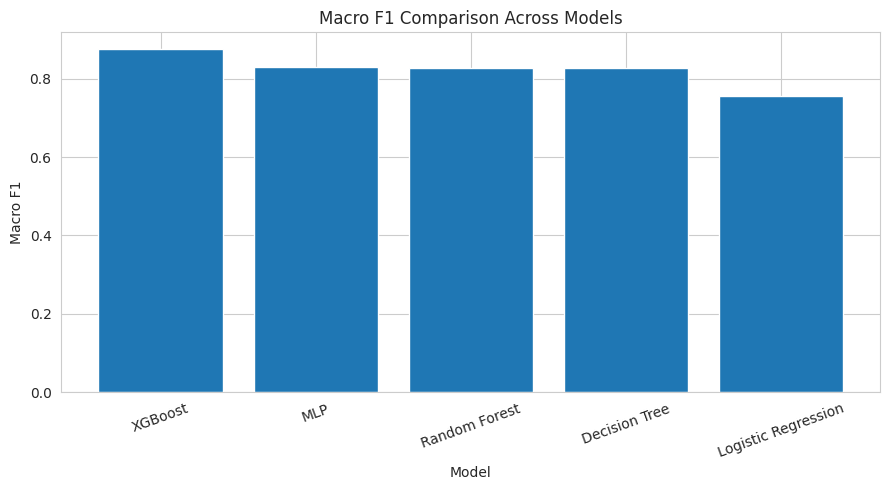

Best model based on macro F1:
model                XGBoost
accuracy              0.9087
precision_macro       0.8773
recall_macro          0.8726
f1_macro              0.8749
auc_roc_ovr_macro     0.9786
Name: 0, dtype: object


In [70]:
import pandas as pd
import matplotlib.pyplot as plt

# Safety check: rebuild results if needed
try:
    results
except NameError:
    results = [logreg_metrics, dt_metrics, rf_metrics, xgb_metrics, mlp_metrics]

# Create summary table
results_df = pd.DataFrame(results)

metric_cols = [
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "auc_roc_ovr_macro"
]

results_df_display = results_df.copy()
results_df_display[metric_cols] = results_df_display[metric_cols].round(4)

# Sort by main comparison metric
results_df_display = results_df_display.sort_values("f1_macro", ascending=False).reset_index(drop=True)

print("Model Comparison Summary")
display(results_df_display)

# Bar chart of key metric
plt.figure(figsize=(9, 5))
plt.bar(results_df_display["model"], results_df_display["f1_macro"])
plt.title("Macro F1 Comparison Across Models")
plt.xlabel("Model")
plt.ylabel("Macro F1")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Identify best model
best_model_row = results_df_display.iloc[0]
print("Best model based on macro F1:")
print(best_model_row)

The model comparison shows that XGBoost was the strongest performer, with the highest macro F1 (0.8749) and the best overall test-set metrics.

The MLP, Random Forest, and Decision Tree all performed reasonably well and were fairly close to one another, while Logistic Regression served as a useful but weaker baseline.

This pattern is consistent with the idea that more flexible nonlinear models are better suited to distinguishing between benign prompts, jailbreak attempts, and injection-style attacks.

The main trade-off is interpretability. Simpler models are easier to explain, but XGBoost provides the best predictive performance.

# Part 3: Explainability

## 3.1 SHAP Analysis

 99%|===================| 2803/2826 [00:31<00:00]       

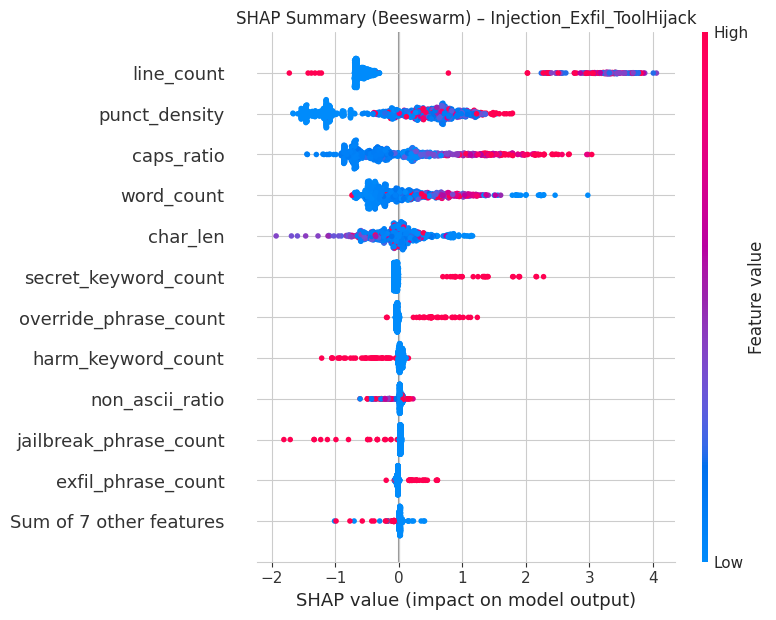

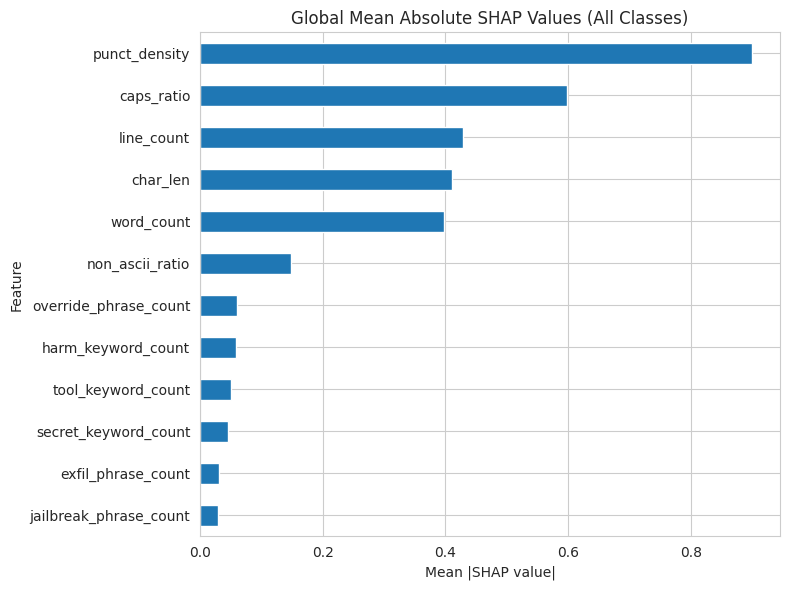

,mean_abs_shap
punct_density,0.9004
caps_ratio,0.5987
line_count,0.4281
char_len,0.4106
word_count,0.3973
non_ascii_ratio,0.1481
override_phrase_count,0.0603
harm_keyword_count,0.0582
tool_keyword_count,0.0499
secret_keyword_count,0.0448


Selected waterfall example index: 298
True class: Injection_Exfil_ToolHijack
Predicted class: Injection_Exfil_ToolHijack

Predicted probabilities:


,probability
Injection_Exfil_ToolHijack,0.9999
Jailbreak,0.0001
Benign,0.0000


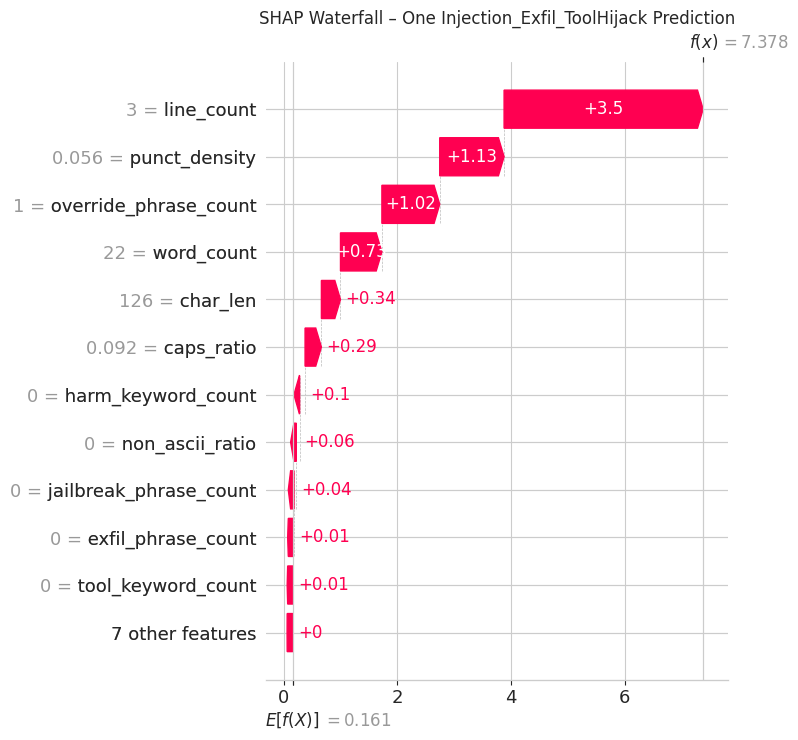

In [72]:
!pip install shap -q

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Use test data for explanation plots
X_shap = X_test.copy()

# Small background sample keeps SHAP faster and more stable
X_background = shap.sample(X_dev, 200, random_state=42)

# Tree SHAP explainer
explainer = shap.TreeExplainer(
    best_xgb,
    data=X_background,
    feature_perturbation="interventional"
)

# Raw SHAP values
shap_values_raw = explainer.shap_values(X_shap)

class_names = list(label_encoder.classes_)

# Choose one class for direction-of-impact interpretation in beeswarm/waterfall
target_class = "Injection_Exfil_ToolHijack"
target_idx = class_names.index(target_class)

# Normalize multiclass output to a 3D array: (n_samples, n_features, n_classes)
if isinstance(shap_values_raw, list):
    shap_values_3d = np.stack(shap_values_raw, axis=2)
else:
    shap_values_3d = shap_values_raw

# Class-specific SHAP values for beeswarm + waterfall
shap_values_class = shap_values_3d[:, :, target_idx]

# Expected value can be scalar or per-class; handle both cases
expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)):
    base_value_class = expected_value[target_idx]
else:
    base_value_class = expected_value

# Build SHAP Explanation object for the selected class
explanation_class = shap.Explanation(
    values=shap_values_class,
    base_values=np.repeat(base_value_class, X_shap.shape[0]),
    data=X_shap.values,
    feature_names=X_shap.columns.tolist()
)

# 1) Summary plot (beeswarm) for selected class
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(explanation_class, max_display=12, show=False)
plt.title("SHAP Summary (Beeswarm) – Injection_Exfil_ToolHijack")
plt.tight_layout()
plt.show()

# 2) Global bar plot using mean absolute SHAP across ALL classes
global_mean_abs = np.abs(shap_values_3d).mean(axis=(0, 2))
global_importance = (
    pd.Series(global_mean_abs, index=X_shap.columns)
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 6))
global_importance.head(12).sort_values().plot(kind="barh")
plt.title("Global Mean Absolute SHAP Values (All Classes)")
plt.xlabel("Mean |SHAP value|")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

display(global_importance.to_frame("mean_abs_shap").round(4))

# 3) Waterfall plot for one specific prediction
y_pred_xgb_enc = best_xgb.predict(X_test)
y_pred_xgb = label_encoder.inverse_transform(y_pred_xgb_enc.astype(int))
y_proba_xgb = best_xgb.predict_proba(X_test)

candidate_mask = (y_test.values == target_class) & (y_pred_xgb == target_class)
candidate_idx = np.where(candidate_mask)[0]

if len(candidate_idx) > 0:
    example_idx = candidate_idx[np.argmax(y_proba_xgb[candidate_idx, target_idx])]
else:
    example_idx = int(np.argmax(y_proba_xgb[:, target_idx]))

print("Selected waterfall example index:", example_idx)
print("True class:", y_test.iloc[example_idx])
print("Predicted class:", y_pred_xgb[example_idx])
print("\nPredicted probabilities:")
display(
    pd.Series(y_proba_xgb[example_idx], index=class_names)
    .sort_values(ascending=False)
    .round(4)
    .to_frame("probability")
)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(explanation_class[example_idx], max_display=12, show=False)
plt.title("SHAP Waterfall – One Injection_Exfil_ToolHijack Prediction")
plt.tight_layout()
plt.show()

The most influential features are punct_density, caps_ratio, line_count, char_len, and word_count. The model relies heavily on the structural stylistic properties of prompts, not just on malicious keywords that may be obvious.

High values of line_count punct_density, and caps_ratio push predictions toward the Injection/Exfil/Tool Hijack class. Higher values of secret_keyword_count, override_phrase_count, and exfil_phrase_count tend to increase the model's confidence in the malicious class.

On the other hand, high values of jailbreak_phrase_count and harm_keyword_count push predictions away from Injection/Exfil/Tool Hijack. This makes sense because those features are more closely associated with other malicious prompt categories, such as Jailbreak. Features such as word_count and char_len appear to have more of a mixed pattern. This suggests that their effect depends on context.

In the waterfall plot, we were able to see that line_count = 3 was the strongest driver for the prediction of Injection/Exfil/Tool Hijack.

These results are useful because they make the model transparent and actionable. The model is able to detect broad prompt characteristics associated with adversarial behavior. This could help analysts understand why a prompt might have been flagged, leading to a design of guardrails aimed at high-risk prompt patterns.

In [73]:
import json

feature_cols = [
    "char_len",
    "word_count",
    "line_count",
    "caps_ratio",
    "punct_density",
    "non_ascii_ratio",
    "has_url",
    "has_email",
    "has_code_block",
    "has_base64_like",
    "override_phrase_count",
    "jailbreak_phrase_count",
    "secret_keyword_count",
    "exfil_phrase_count",
    "tool_keyword_count",
    "harm_keyword_count",
    "mentions_system_or_policy",
    "external_destination_present"
]

with open("feature_columns.json", "w") as f:
    json.dump(feature_cols, f, indent=2)

print("feature_columns.json created")
print(feature_cols)

feature_columns.json created
['char_len', 'word_count', 'line_count', 'caps_ratio', 'punct_density', 'non_ascii_ratio', 'has_url', 'has_email', 'has_code_block', 'has_base64_like', 'override_phrase_count', 'jailbreak_phrase_count', 'secret_keyword_count', 'exfil_phrase_count', 'tool_keyword_count', 'harm_keyword_count', 'mentions_system_or_policy', 'external_destination_present']


In [74]:
import json

with open("feature_columns.json", "r") as f:
    feature_cols = json.load(f)

print("Number of features:", len(feature_cols))
print(feature_cols)

Number of features: 18
['char_len', 'word_count', 'line_count', 'caps_ratio', 'punct_density', 'non_ascii_ratio', 'has_url', 'has_email', 'has_code_block', 'has_base64_like', 'override_phrase_count', 'jailbreak_phrase_count', 'secret_keyword_count', 'exfil_phrase_count', 'tool_keyword_count', 'harm_keyword_count', 'mentions_system_or_policy', 'external_destination_present']
